<a href="https://colab.research.google.com/github/gunvarawork-cpu/code-repository/blob/main/LAB_3/LAB3_Classification_6606614623.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install earthengine-api geemap seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 11.8 MB/s eta 0:00:00


In [2]:
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

ee.Authenticate()
ee.Initialize(project='ee-gunvarawoon')

Accuracy (ความแม่นยำ): 0.7835051546391752
Kappa (ค่าแคปป้า): 0.7181013008580127
F1-score (คะแนน F1) สำหรับแต่ละคลาส: [0, 0.9268292682926829, 1.0, 0.8070175438596492, 0.3846153846153846, 0.25]
โดยค่า F1-score จะแสดงค่าสำหรับแต่ละคลาสตามลำดับที่โมเดลได้เรียนรู้และจำแนกครับ



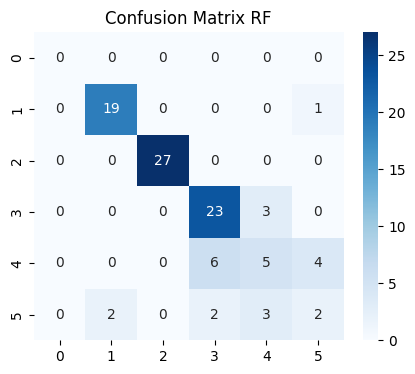

  Feature  Importance
0     B11   89.504364
7    NDWI   76.170692
1      B2   76.086677
3      B4   74.427081
4      B8   72.039955
2      B3   71.096054
5    NDBI   68.013407
6    NDVI   65.644671


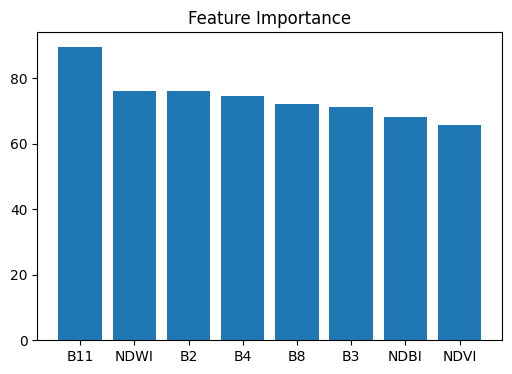

Accuracy without NDVI: 0.8026315789473685


Map(center=[14.250050034795764, 100.59999999999953], controls=(WidgetControl(options=['position', 'transparent…

In [8]:
# =============================
# ROI
# =============================
roi = ee.Geometry.Polygon([
    [[100.40,14.40],
     [100.80,14.40],
     [100.80,14.10],
     [100.40,14.10],
     [100.40,14.40]]
])

# =============================
# LOAD TRAINING
# =============================
training = ee.FeatureCollection(
    'projects/ee-gunvarawoon/assets/training_data_ayutthaya'
)

# =============================
# IMAGE
# =============================
def maskS2(image):
    qa = image.select('QA60')
    return image.updateMask(
        qa.bitwiseAnd(1 << 10).eq(0).And(
        qa.bitwiseAnd(1 << 11).eq(0))
    )

image = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
         .filterBounds(roi)
         .filterDate('2024-01-01','2024-03-31')
         .map(maskS2)
         .median()
         .clip(roi))

# =============================
# FEATURES
# =============================
bands = image.select(['B2','B3','B4','B8','B11'])

ndvi = image.normalizedDifference(['B8','B4']).rename('NDVI')
ndwi = image.normalizedDifference(['B3','B8']).rename('NDWI')
ndbi = image.normalizedDifference(['B11','B8']).rename('NDBI')

features = bands.addBands([ndvi, ndwi, ndbi])

# =============================
# SAMPLING
# =============================
samples = features.sampleRegions(
    collection=training,
    properties=['Class'],
    scale=10
)

samples = samples.randomColumn('random')
train = samples.filter(ee.Filter.lt('random',0.8))
test = samples.filter(ee.Filter.gte('random',0.8))

# =============================
# RANDOM FOREST (100 trees)
# =============================
rf = ee.Classifier.smileRandomForest(100).train(
    features=train,
    classProperty='Class',
    inputProperties=features.bandNames()
)

# =============================
# ACCURACY
# =============================
test_classified = test.classify(rf)
cm = test_classified.errorMatrix('Class','classification')

accuracy_val = cm.accuracy().getInfo()
kappa_val = cm.kappa().getInfo()

# F1-score
producers_raw = cm.producersAccuracy().getInfo()
users_raw = cm.consumersAccuracy().getInfo()

# Flatten producers_raw (list of lists to list of numbers)
producers = [p[0] for p in producers_raw]
# Extract the single list of user accuracies
users = users_raw[0]

f1 = []
for p_val, u_val in zip(producers, users):
    if (p_val + u_val) == 0:
        f = 0
    else:
        f = 2 * (p_val * u_val) / (p_val + u_val)
    f1.append(f)

print(f"Accuracy (ความแม่นยำ): {accuracy_val}")
print(f"Kappa (ค่าแคปป้า): {kappa_val}")
print(f"F1-score (คะแนน F1) สำหรับแต่ละคลาส: {f1}")
print("โดยค่า F1-score จะแสดงค่าสำหรับแต่ละคลาสตามลำดับที่โมเดลได้เรียนรู้และจำแนกครับ\n")

# =============================
# CONFUSION MATRIX PLOT
# =============================
cm_np = np.array(cm.getInfo())

plt.figure(figsize=(5,4))
sns.heatmap(cm_np, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix RF")
plt.savefig("confusion_matrix_RF.png", dpi=300)
plt.show()

# =============================
# FEATURE IMPORTANCE
# =============================
importance = rf.explain().get('importance').getInfo()

df = pd.DataFrame({
    "Feature": list(importance.keys()),
    "Importance": list(importance.values())
}).sort_values(by="Importance", ascending=False)

print(df)

plt.figure(figsize=(6,4))
plt.bar(df["Feature"], df["Importance"])
plt.title("Feature Importance")
plt.savefig("feature_importance.png", dpi=300)
plt.show()

# =============================
# FEATURE REMOVAL TEST
# =============================
features_no_ndvi = features.select(['B2','B3','B4','B8','B11','NDWI','NDBI'])

samples_no = features_no_ndvi.sampleRegions(
    collection=training,
    properties=['Class'],
    scale=10
)

samples_no = samples_no.randomColumn('random')
train_no = samples_no.filter(ee.Filter.lt('random',0.8))
test_no = samples_no.filter(ee.Filter.gte('random',0.8))

rf_no = ee.Classifier.smileRandomForest(100).train(
    features=train_no,
    classProperty='Class',
    inputProperties=features_no_ndvi.bandNames()
)

cm_no = test_no.classify(rf_no).errorMatrix('Class','classification')

print("Accuracy without NDVI:", cm_no.accuracy().getInfo())

# =============================
# MAP
# =============================
rf_map = features.classify(rf)

Map = geemap.Map()
Map.centerObject(roi, 11)

Map.addLayer(
    rf_map,
    {'min':1,'max':5,'palette':['blue','cyan','yellow','green','red']},
    'RF Classification'
)
Map